In [1]:
# Day 02 - Text Mining (Word Frequency)

text = """
Data science is amazing. Data analysis helps find patterns.
Data is powerful and data is everywhere.
"""

# Convert to lowercase
text = text.lower()

# Remove punctuation
import string
for p in string.punctuation:
    text = text.replace(p, "")

# Split into words
words = text.split()

# Count frequency
word_freq = {}

for word in words:
    if word in word_freq:
        word_freq[word] += 1
    else:
        word_freq[word] = 1

# Print result
print("Word Frequency:")
for word, count in word_freq.items():
    print(word, ":", count)

Word Frequency:
data : 4
science : 1
is : 3
amazing : 1
analysis : 1
helps : 1
find : 1
patterns : 1
powerful : 1
and : 1
everywhere : 1


In [2]:
# Top 3 frequent words
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

print("\nTop 3 words:")
for word, count in sorted_words[:3]:
    print(word, ":", count)


Top 3 words:
data : 4
is : 3
science : 1


In [3]:
stopwords = ["is", "and", "the", "a", "an"]

filtered_words = []

for word in words:
    if word not in stopwords:
        filtered_words.append(word)

In [4]:
total_words = len(filtered_words)

tf = {}

for word in filtered_words:
    if word in tf:
        tf[word] += 1
    else:
        tf[word] = 1

# Convert to TF values
for word in tf:
    tf[word] = tf[word] / total_words

print("\nTF Values:")
for word, value in tf.items():
    print(word, ":", round(value, 3))


TF Values:
data : 0.333
science : 0.083
amazing : 0.083
analysis : 0.083
helps : 0.083
find : 0.083
patterns : 0.083
powerful : 0.083
everywhere : 0.083


In [5]:
documents = [
    "data science is fun",
    "machine learning is powerful",
    "data analysis and machine learning"
]

In [6]:
documents = [
    "data science is fun",
    "machine learning is powerful",
    "data analysis and machine learning"
]

In [7]:
import math

N = len(documents)

idf = {}

for doc in documents:
    words = set(doc.split())
    for word in words:
        idf[word] = idf.get(word, 0) + 1

for word in idf:
    idf[word] = math.log(N / idf[word])

In [10]:
tfidf = {}

for word in tf:
    if word in idf:
        tfidf[word] = tf[word] * idf[word]

In [11]:
sorted_words = sorted(tfidf.items(), key=lambda x: x[1], reverse=True)

for word, score in sorted_words[:5]:
    print(word, score)

data 0.13515503603605478
science 0.0915510240556758
analysis 0.0915510240556758
powerful 0.0915510240556758


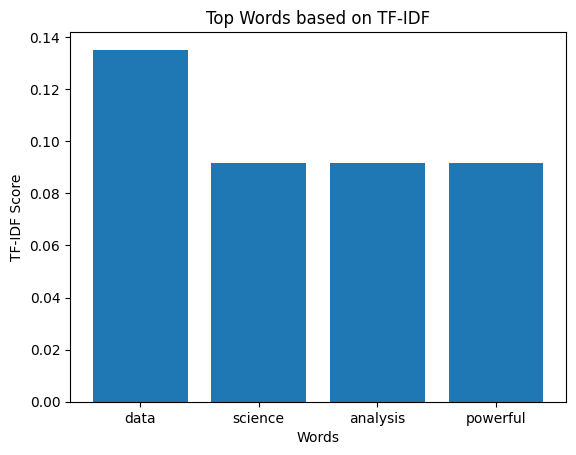

In [12]:
import matplotlib.pyplot as plt

# Get top 5 words
sorted_words = sorted(tfidf.items(), key=lambda x: x[1], reverse=True)
top_words = sorted_words[:5]

words = [w[0] for w in top_words]
scores = [w[1] for w in top_words]

# Plot bar chart
plt.bar(words, scores)
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.title("Top Words based on TF-IDF")
plt.show()

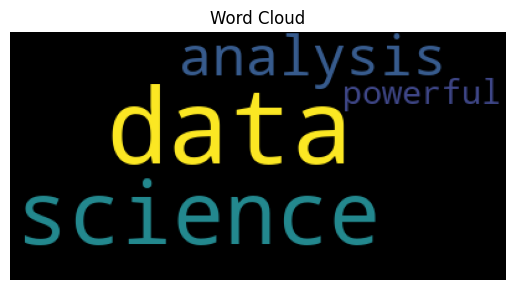

In [13]:
from wordcloud import WordCloud

# Create word cloud
wordcloud = WordCloud().generate_from_frequencies(tfidf)

# Show it
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [14]:
documents = [
    "This product is amazing and useful",
    "Very bad quality and waste of money",
    "Good value and nice quality"
]

In [15]:
positive_words = ["good", "amazing", "nice"]
negative_words = ["bad", "waste"]

for doc in documents:
    score = 0
    for word in doc.split():
        if word in positive_words:
            score += 1
        elif word in negative_words:
            score -= 1
    
    if score > 0:
        print(doc, "→ Positive")
    else:
        print(doc, "→ Negative")

This product is amazing and useful → Positive
Very bad quality and waste of money → Negative
Good value and nice quality → Positive


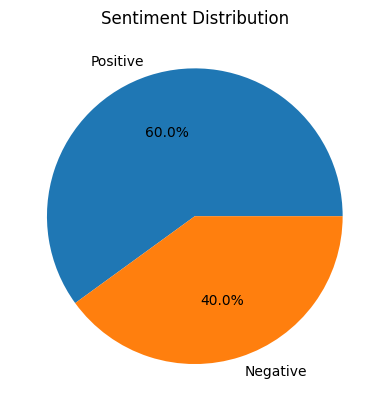

In [16]:
labels = ["Positive", "Negative"]
sizes = [3, 2]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.show()

In [17]:
bigrams = []

for doc in documents:
    words = doc.split()
    for i in range(len(words)-1):
        bigrams.append(words[i] + " " + words[i+1])

print(bigrams)

['This product', 'product is', 'is amazing', 'amazing and', 'and useful', 'Very bad', 'bad quality', 'quality and', 'and waste', 'waste of', 'of money', 'Good value', 'value and', 'and nice', 'nice quality']


In [18]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(tfidf)